In [1]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import pandas as pd
from collections import namedtuple
plt.style.use('dark_background')

In [2]:
def _readline(ser: serial.Serial, timeout: int):
    _t0 = time.time()
    s = ""
    while (time.time() - _t0 < timeout):
        if ser.in_waiting > 0:
            c = ser.read()
            if (c > bytes([0])) and (c < bytes([128])):
                if (c == b'\n') or (c == b'\r'):
                    if s == "":
                        pass
                    elif len(s) > 2:
                        return s
                else:
                    s += c.decode()
                
    return s

def _wait_for_line(ser: serial.Serial, target: str, input: str = "", timeout: float = 1.0, print_out = False):
    if input != "":
        ser.write((input + "\n").encode())
    t0 = time.time()
    timeout_t = t0 + timeout
    condition = False
    while (condition == False):
        _l = _readline(ser, 0.25)
        if target in _l:
            condition = True
        if print_out:
            if _l != "": print(_l)
        if time.time() > timeout_t:
            break

    return condition

    
def _parse_data_line(l:str)->dict:
    ret = {}
    if len(l) > 5:
        if (l[:2] == "T:") and ("," in l) and (":" in l):
            items = [n.split(':') for n in l.split(',') if ":" in n]
            for i in items:
                k = i[0]
                v = i[1]
                if len(k) > 0:
                    if v.isdecimal():
                        ret.update({k: int(v)})
                    if (v.count(".") == 1) and v.replace(".", "0").isdecimal():
                        ret.update({k: float(v)})

    return ret        


def Trigger(ser: serial.Serial) -> dict:
    ser.write(b"G")
    ser.flush()
    _ret = _parse_data_line(_readline(ser, .5))
    return _ret

def Ambit_actinic(ser: serial.Serial, v:int)->int:
    if (v > 255): return -1
    ser.write(bytes([65, v]))
    ser.flush()
    return v
    

def DAC_set(ser: serial.Serial, ch:int, v:int):
    ret = False
    if (ch == 2) or (ch == 4):
        if (v > -1) and (v < 4095):
            ret = _wait_for_line(ser, target = "Done", input = f'DAC,{ch},{v},\n', print_out=False)
    if ret == False: 
        print("DAC_set error", ch, v)
        return -1
    return v

def DAC_ONOFF(ser: serial.Serial, ch:int, onoff:bool):
    if onoff:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_ON,{ch},\n', print_out=False)
    else:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,{ch},\n', print_out=False)
        else:
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,0,\n', print_out=False)

# plot autoscale
def autoscale(data: list, axis:plt.Axes):
    if len(data) == 0: return
    if len(data) == 1: 
        axis.set_ylim([data[0]-1, data[0]+1])
        return    
    l, h = axis.get_ylim()
    x, d = np.min(data), np.max(data)
    r = d - x

    _l, _h, a = l, h, False
    if (x < l) or (l < x - r):
        _l = x - 0.05 * r
        a = True
    if (d > h) or (h > l + r):
        _h = d + 0.05 * r
        a = True
    if a and _l != _h:
        axis.set_ylim([_l, _h])

In [48]:
protocol = [['M',     100,     0.001,    0]]

In [49]:
ser = serial.Serial("COM9", 115200, rtscts=False)
START_TIME = time.time()
try:
    _wait_for_line(ser, target = "NEW Name", input = "hello", print_out=True)
    if not _wait_for_line(ser, target = "Start", input = "ff,190", print_out=True):
        ser.write(b'E\n')
        raise NameError("Function not started")
    
    if not _wait_for_line(ser, target = "Run", input = "", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not started")           


    _act_ambit, _act_blue, _act_red, act_blue, act_red = -1, -1, -1, 0, 0
    _data = []
    for _l in protocol:

        if _l[0] == 'M' and len(_l) == 4: # Run measurement
            
            if (_act_ambit != _l[3]):   # Set ambit actinic
                _act_ambit = Ambit_actinic(ser, _l[3])
            if (_l[1] < 1): continue    # no data
            for _ in range(_l[1]):
                _ts = time.perf_counter()
                _ret = Trigger(ser)
                if _ret != {}: 
                    _ret.update({"ACT":_act_ambit,"Blue":act_blue,"Red":act_red}.copy())
                    _data.append(_ret)
                _elapsed = time.perf_counter() - _ts
                if _elapsed < _l[2]: time.sleep(_l[2] - _elapsed)
        

        if _l[0] == 'W' and len(_l) == 2:
            time.sleep(_l[1])

    if not _wait_for_line(ser, target = "Stop", input = "E", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not Stopped")

finally:
    ser.close()


NEW Name Here Ready
Start
Run
Stop


In [6]:
data = pd.DataFrame(_data)

In [124]:
data.attrs['OFFSET'] = 1

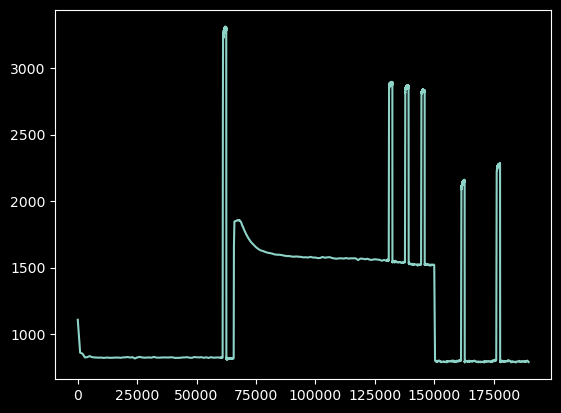

In [118]:
plt.plot(data['T'], data['B'])